# Sensitivity analysis

This notebook contains the code used to fit the surrogate model and generate the plots for **Figure 13** and **Figure 13—figure supplement 3** of:

Shevtosva NA, Lockhart AB, Rybak IA, Magnuson DSK, Danner SM. **Reorganization of spinal neural connectivity following recovery after thoracic spinal cord injury: insights from computational modelling.** *bioRxiv*, 2025.05.17.654682; doi: [10.1101/2025.05.17.654682](https://doi.org/10.1101/2025.05.17.654682)

The simulations with parameter variations and calculation of the distance metric between frequency-dependent gait distributions are performed by **`sensitivity_run.py`**.  
This notebook loads the results generated by that script and produces the surrogate fits and visualizations.

Copyright (c) 2025 The Authors. Licensed under [GNU GPL v3](https://www.gnu.org/licenses/gpl-3.0).

In [ ]:
try:
    import google.colab
    IN_COLAB = True
except:  # noqa: E722
    IN_COLAB = False

if IN_COLAB:
    !git clone -b sensitivity https://github.com/dannerlab/rat-sci-locomotion-model
    %cd rat-sci-locomotion-model

In [2]:
from sklearn.metrics import r2_score
import numpy as np
import yaml
import xgboost as xgb
import io
from SALib import ProblemSpec
from copy import copy
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
mpl.rcParams['pdf.fonttype'] = 42  # TrueType font
mpl.rcParams['ps.fonttype'] = 42   # for EPS compatibility too

In [3]:
class CustomCDumper(yaml.CDumper):
    """ Custom YAML CDumper that forces sequences (lists) to be in flow style []. """
def is_primitive_list(lst):
    return all(isinstance(item, (str, int, float, bool, type(None))) for item in lst)
def represent_list(dumper, data):
    flow_style = is_primitive_list(data)  # Use `[]` only for primitive lists
    return dumper.represent_sequence("tag:yaml.org,2002:seq", data, flow_style=flow_style)
CustomCDumper.add_representer(list, represent_list)

In [4]:
def sobol_sensitivity(model, n, par_names,bounds):
    if isinstance(bounds[0], (int, float)):
        bounds_array = np.array([bounds] * n)
    else:
        bounds_array = np.array(bounds)  # shape (d, 2), e.g., [[low1, high1], ...]
    
    sp = ProblemSpec({
        'names': par_names,  # list of length d
        'bounds': bounds_array,  # shape (d, 2), e.g., [[low1, high1], ...]
        'outputs': ['Y']
    })

    N = 1024*16
    sp.sample_sobol(N, calc_second_order=True)
    Y = model.predict(np.exp(sp.samples))
    sp.set_results(Y)

    sp.analyze_sobol()
    return sp.analysis

def calculate_surrogate_sensitivity(s_config_fn,i_run,save_to_yaml=False):
    with open(s_config_fn, 'r') as file:
        s_config = yaml.safe_load(file)
    data_file_fn = s_config['run'][i_run]['out_filename']+'.npz'
    data = np.load(data_file_fn, allow_pickle=True)

    X_train = data['X_train']
    X_val = data['X_val']
    y_train = data['y_train']
    y_val = data['y_val']
    par_names = data['par_names']

    if len(y_val.shape) == 1:
        y_val = y_val.reshape(-1, 1)
        y_train = y_train.reshape(-1, 1)


    scoring_fns = copy(s_config['scoring_fn'])
    if not isinstance(scoring_fns, list):
        scoring_fns = [scoring_fns]
    
    models = []
    for score, i in zip(scoring_fns, range(len(scoring_fns))):
        print(f"Analyzing output variable {i+1}/{len(scoring_fns)} {score}")
        y_train_i = y_train[:, i]
        y_val_i = y_val[:, i]
        
        model = xgb.XGBRegressor(
            objective='reg:squarederror',
            n_estimators=3000,
            learning_rate=0.05,
            max_depth=4,
            min_child_weight=20,
            subsample=0.7,
            colsample_bytree=0.6,
            reg_lambda=10.0,
            n_jobs=-1,
            early_stopping_rounds=100, 
            eval_metric='rmse'
        )
        model.fit(
            X_train, y_train_i,
            eval_set=[(X_val, y_val_i)],
            verbose=False
        )
        models.append(model)
        r2_train = r2_score(y_train_i, model.predict(X_train))
        r2_val = r2_score(y_val_i, model.predict(X_val))

        output = io.StringIO()
        
        output.write(f"train R²: {r2_train}\n")
        output.write(f"val   R²: {r2_val}\n")

        result_str = output.getvalue()
        print(result_str)

        # Ensure the score key exists in the YAML structure
        if score not in s_config['run'][i_run]:
            s_config['run'][i_run][score] = {}
        s_config['run'][i_run][score]['xgboost_r2'] = {'train': float(r2_train), 'val': float(r2_val)}

        
        scale = s_config['scale_exp']
        sobol_results = sobol_sensitivity(model,X_train.shape[1],par_names,[-np.log(scale),np.log(scale)])
        sobol_dict = {}
        
        for k in ['S1', 'S1_conf', 'ST', 'ST_conf']:
            if k in sobol_results:
                sobol_dict[k] = {str(name): float(val) for name, val in zip(par_names, sobol_results[k])}
        for k in ['S2', 'S2_conf']:
            if k in sobol_results:
                # S2 is a matrix, flatten upper triangle with names
                d = len(par_names)
                S2 = sobol_results[k]
                S2_named = {}
                for i in range(d):
                    for j in range(i+1, d):
                        S2_named[f"{par_names[i]} x {par_names[j]}"] = float(S2[i, j])
                sobol_dict[k] = S2_named
        s_config['run'][i_run][score]['sobol'] = sobol_dict
        s_config['run'][i_run][score]['metadata'] = {'n_samples': X_train.shape[0], 
                                                    'n_samples_val': X_val.shape[0], 
                                                    'range':[float(np.min(X_train)), float(np.max(X_train))],
                                                    'y_range':[float(np.min(y_train_i)), float(np.max(y_train_i))]}
    if save_to_yaml:
        with open(s_config_fn, 'w') as file:
            yaml.dump(s_config, file,default_flow_style=False, sort_keys=False, Dumper=CustomCDumper)
    return s_config, models


In [5]:
def plot_sensitivity(s_config,ax,par_names=None,transform=None,s_indices=['S1','ST']):
    emd_data = s_config['run'][-1]['emd']['sobol']

    if par_names is None:
        par_names = list(emd_data['ST'].keys())

    emd_data = s_config['run'][-1]['emd']['sobol']
    
    ST_values = [emd_data['ST'][par] for par in par_names]
    S1_values = [emd_data['S1'][par] for par in par_names]
    S1_conf_values = [emd_data['S1_conf'][par] for par in par_names]
    ST_conf_values = [emd_data['ST_conf'][par] for par in par_names]
    x = np.arange(len(par_names))*-1
    width = 0.35
    x_off = width/2
    if len(s_indices) == 1:
        x_off = 0
    if transform == "log":
        ax.set_xscale("log")
    if 'S1' in s_indices:
        _ = ax.barh(x - x_off, S1_values, height=width, xerr=S1_conf_values, label='First-order (S1)', capsize=5)
    if 'ST' in s_indices:
        _ = ax.barh(x + x_off, ST_values, height=width, xerr=ST_conf_values, label='Total-order (ST)', capsize=5)
    ax.set_xlim(0, 1.1)
    ax.set_yticks(x)
    ax.set_yticklabels(par_names)
    
    if len(s_indices) > 1:
        ax.legend()
    elif 'S1' in s_indices:
        ax.set_xlabel('First-order sensitivity')
    elif 'ST' in s_indices:
        ax.set_xlabel('Total-order sensitivity')
    plt.tight_layout()
    sns.despine()


## Figure 13: First and total order sensitivity indices for hemisection and contusion model

In [6]:
s_config_contusion, _ = calculate_surrogate_sensitivity('./sensitivity/sensitivity_contusion_final.yaml', i_run=0)
s_config_hemisection, _ = calculate_surrogate_sensitivity('./sensitivity/sensitivity_hemisection_final.yaml', i_run=0)

Analyzing output variable 1/1 emd
train R²: 0.9707057524441359
val   R²: 0.9371094443958136

Analyzing output variable 1/1 emd
train R²: 0.9879135389092211
val   R²: 0.9498713005425579



(0.0, 1.0)

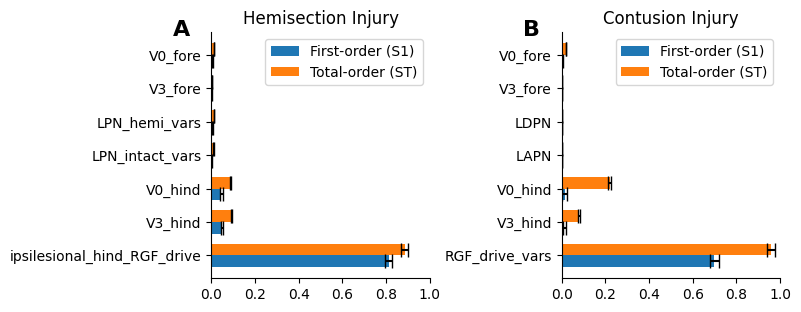

In [7]:
s_indices=['ST','S1']
fig, axs = plt.subplots(1,2,figsize=(8, 3),sharex=True)
plot_sensitivity(s_config_hemisection, axs[0],['V0_fore','V3_fore','LPN_hemi_vars','LPN_intact_vars','V0_hind','V3_hind','ipsilesional_hind_RGF_drive'],s_indices=s_indices)

plot_sensitivity(s_config_contusion, axs[1],['V0_fore','V3_fore','LDPN','LAPN','V0_hind','V3_hind','RGF_drive_vars'],s_indices=s_indices)

axs[0].set_title('Hemisection Injury')
axs[1].set_title('Contusion Injury')
labels = ['A', 'B']
for ax, label in zip(axs.flat, labels):
    ax.text(-0.1, 1.05, label, transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
axs[0].set_xlim((0,1))

## Figure 13—figure supplement 3: Predicted Earth Mover's distance to baseline as a function of lumbar V0/V3 commissural interneuron connectivity

In [8]:
# use sensitivity data obtained without varying drive parameters
s_config_hemisection_wo_drive, models_hemisection = calculate_surrogate_sensitivity('./sensitivity/sensitivity_hemisection_wo_drive.yaml', i_run=0)
s_config_contusion_wo_drive, models_contusion = calculate_surrogate_sensitivity('./sensitivity/sensitivity_contusion_wo_drive.yaml', i_run=0)

Analyzing output variable 1/1 emd
train R²: 0.9912707851721061
val   R²: 0.9763235349338466

Analyzing output variable 1/1 emd
train R²: 0.9490361031586345
val   R²: 0.8934524786157524



(0.0, 1.0)

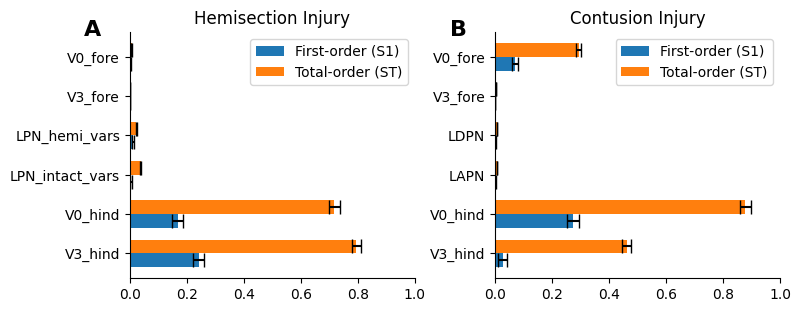

In [9]:
# Sensitivity indices without varying drive parameters (not shown in paper)
s_indices=['ST','S1']
fig, axs = plt.subplots(1,2,figsize=(8, 3),sharex=True)
plot_sensitivity(s_config_hemisection_wo_drive, axs[0],['V0_fore','V3_fore','LPN_hemi_vars','LPN_intact_vars','V0_hind','V3_hind'],s_indices=s_indices)
plot_sensitivity(s_config_contusion_wo_drive, axs[1],['V0_fore','V3_fore','LDPN','LAPN','V0_hind','V3_hind'],s_indices=s_indices)

axs[0].set_title('Hemisection Injury')
axs[1].set_title('Contusion Injury')
labels = ['A', 'B']
for ax, label in zip(axs.flat, labels):
    ax.text(-0.1, 1.05, label, transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
axs[0].set_xlim((0,1))

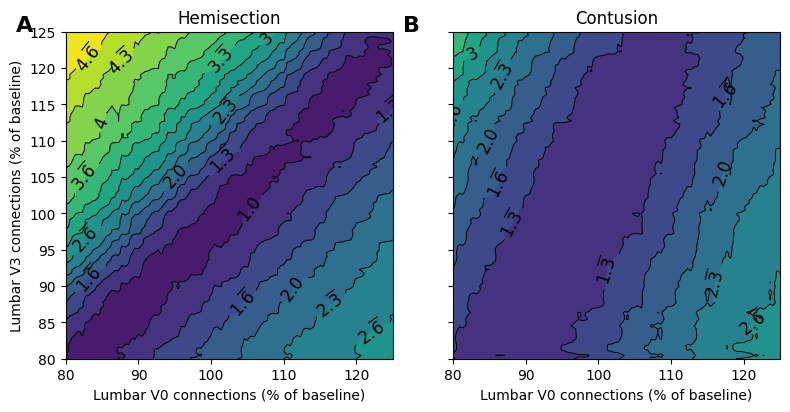

In [10]:
def plot_surrogate_contour(surrogate, d, i_v0, i_v3, n_grid=50, levels=None, v_min_max=None,ax=None):
    baseline_params = np.ones(d)
    scale = np.linspace(0.8, 1.25, n_grid)
    V0_grid, V3_grid = np.meshgrid(scale, scale)

    # Allocate array for predicted EMD
    EMD_pred = np.zeros_like(V0_grid)
    
    # Flatten the V0 and V3 grids for batch prediction
    v0_flat = V0_grid.ravel()
    v3_flat = V3_grid.ravel()
    n_points = v0_flat.size

    # Create a parameter matrix: one row per grid point
    param_mat = np.repeat(baseline_params[np.newaxis, :], n_points, axis=0)

    # Scale V0 and V3 columns
    param_mat[:, i_v0] = baseline_params[i_v0] * v0_flat
    param_mat[:, i_v3] = baseline_params[i_v3] * v3_flat

    # Batch prediction
    pred = surrogate.predict(param_mat)          
    pred = np.squeeze(pred)                      
    EMD_pred[:, :] = pred.reshape(V0_grid.shape)

    # Convert scale to percent for more intuitive axes
    V0_percent = V0_grid * 100
    V3_percent = V3_grid * 100

    if ax is None:
        _, ax = plt.subplots()

    # Choose a common set of levels for both filled and line contours
    if levels is None:
        levels = np.linspace(EMD_pred.min(), EMD_pred.max(), 9)
    else:
        if levels[0] > EMD_pred.min():
            levels[0] = EMD_pred.min()
        if levels[-1] < EMD_pred.max():
            levels[-1] = EMD_pred.max()

    # Filled contour background
    #cf = ax.contourf(V0_percent, V3_percent, EMD_pred,
    #                levels=levels, cmap='viridis')
    if v_min_max is not None:
        v_min, v_max = v_min_max
        #pcm = ax.pcolormesh(V0_percent, V3_percent, EMD_pred,
        #                    shading='gouraud', cmap='viridis', vmin=v_min, vmax=v_max)
        cf = ax.contourf(V0_percent, V3_percent, EMD_pred,
                    levels=levels, cmap='viridis',vmin=v_min, vmax=v_max)
    else:
        #pcm = ax.pcolormesh(V0_percent, V3_percent, EMD_pred,
        #                shading='gouraud', cmap='viridis')
        cf = ax.contourf(V0_percent, V3_percent, EMD_pred,
                    levels=levels, cmap='viridis')

    # Black contour lines at the same levels
    cs = ax.contour(V0_percent, V3_percent, EMD_pred,
                    levels=levels, colors='k', linewidths=0.7)

    # Label the contour lines
    def fmt_repeating(x, tol=1e-5):
        frac = x - np.floor(x)
        n = int(np.floor(x))

        if abs(frac - 1/3) < tol:
            return rf"${n}.\!\overline{{3}}$"
        elif abs(frac - 2/3) < tol:
            return rf"${n}.\!\overline{{6}}$"
        elif abs(frac - 0) < tol:
            return rf"${n}.0$"
        else:
            return f"{x:.0f}"
        
    ax.clabel(cs, inline=True, fontsize=12, fmt=fmt_repeating)
    ax.set_xlabel("Lumbar V0 connections (% of baseline)")
    ax.set_aspect('equal', adjustable='box')
fig, axs = plt.subplots(1,2,figsize=(8, 4),sharex=True,sharey=True)
plot_surrogate_contour(models_hemisection[0], 6,4,5,n_grid=100,v_min_max=[0.5,5],levels=np.linspace(2/3,5.0,14),ax=axs[0])
plot_surrogate_contour(models_contusion[0], 6,4,5,n_grid=100,v_min_max=[0.5,5],levels=np.linspace(2/3,5.0,14),ax=axs[1])
axs[0].set_title('Hemisection')
axs[0].set_ylabel("Lumbar V3 connections (% of baseline)")
axs[1].set_title('Contusion')
labels = ['A', 'B']
for ax, label in zip(axs.flat, labels):
    ax.text(-0.1, 1.05, label, transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

plt.tight_layout()